Project Name: Object Detection on Acoustic Imagery

Link for Dataset Used: https://www.kaggle.com/datasets/mazenkhaled202201534/underwater-acoustic-target-detection-uatddataset

In [1]:
!pip install -q ultralytics pillow lxml tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 17.4 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import shutil
import xml.etree.ElementTree as ET
from PIL import Image
from tqdm import tqdm


In [3]:
CLASS_MAP = {
    "ball": 0,
    "circle cage": 1,
    "cube": 2,
    "cylinder": 3,
    "human body": 4,
    "metal bucket": 5,
    "plane": 6,
    "rov": 7,
    "square cage": 8,
    "tyre": 9
}

BASE_INPUT = "/kaggle/input/underwater-acoustic-target-detection-uatddataset"
BASE_YOLO = "/kaggle/working/UATD_YOLO"


In [4]:
if os.path.exists(BASE_YOLO):
    shutil.rmtree(BASE_YOLO)

for s in ["train", "val"]:
    os.makedirs(f"{BASE_YOLO}/images/{s}", exist_ok=True)
    os.makedirs(f"{BASE_YOLO}/labels/{s}", exist_ok=True)


In [5]:
def convert_xml(xml_path, img_w, img_h):
    root = ET.parse(xml_path).getroot()
    lines = []

    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        if name not in CLASS_MAP:
            continue

        box = obj.find("bndbox")
        xmin, ymin, xmax, ymax = map(float, [
            box.find("xmin").text,
            box.find("ymin").text,
            box.find("xmax").text,
            box.find("ymax").text
        ])

        x = ((xmin + xmax) / 2) / img_w
        y = ((ymin + ymax) / 2) / img_h
        w = (xmax - xmin) / img_w
        h = (ymax - ymin) / img_h

        lines.append(f"{CLASS_MAP[name]} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")

    return lines


In [6]:
def build_split(img_dir, ann_dir, out_img, out_lbl):
    for xml in tqdm(os.listdir(ann_dir)):
        if not xml.endswith(".xml"):
            continue

        xml_path = os.path.join(ann_dir, xml)
        root = ET.parse(xml_path).getroot()

        fname = root.find("file/filename").text.strip()

        img_path = None
        for ext in [".bmp", ".jpg", ".png", ".jpeg"]:
            p = os.path.join(img_dir, fname + ext)
            if os.path.exists(p):
                img_path = p
                break

        if img_path is None:
            continue  # skip broken reference

        try:
            img = Image.open(img_path).convert("RGB")
        except:
            continue  # skip corrupted image

        img_name = fname + ".jpg"
        img.save(os.path.join(out_img, img_name), quality=90)

        w, h = img.size
        labels = convert_xml(xml_path, w, h)
        if not labels:
            continue

        with open(os.path.join(out_lbl, fname + ".txt"), "w") as f:
            f.write("\n".join(labels))


In [7]:
build_split(
    f"{BASE_INPUT}/UATD_Training/UATD_Training/images",
    f"{BASE_INPUT}/UATD_Training/UATD_Training/annotations",
    f"{BASE_YOLO}/images/train",
    f"{BASE_YOLO}/labels/train"
)

build_split(
    f"{BASE_INPUT}/UATD_Test_1/UATD_Test_1/images",
    f"{BASE_INPUT}/UATD_Test_1/UATD_Test_1/annotations",
    f"{BASE_YOLO}/images/val",
    f"{BASE_YOLO}/labels/val"
)

build_split(
    f"{BASE_INPUT}/UATD_Test_2/UATD_Test_2/images",
    f"{BASE_INPUT}/UATD_Test_2/UATD_Test_2/annotations",
    f"{BASE_YOLO}/images/val",
    f"{BASE_YOLO}/labels/val"
)


100%|██████████| 800/800 [00:41<00:00, 19.23it/s]


In [8]:
with open(f"{BASE_YOLO}/data.yaml", "w") as f:
    f.write(f"""
path: {BASE_YOLO}
train: images/train
val: images/val
nc: 10
names: {list(CLASS_MAP.keys())}
""")


In [9]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
model.train(
    data=f"{BASE_YOLO}/data.yaml",
    epochs=20,
    imgsz=640,
    batch=8,
    device=0,
    workers=2
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/UATD_YOLO/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, i

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7be2e1e067e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0

In [10]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")



 Image: 00436.bmp
 plane: 0.71

 Image: 00352.bmp
 rov: 0.53

 Image: 00291.bmp
 tyre: 0.83
 ball: 0.83

 Image: 00215.bmp
 plane: 0.80

 Image: 00120.bmp
 tyre: 0.72
 ball: 0.69

 Image: 00061.bmp
 square cage: 0.75
 cube: 0.72

 Image: 00174.bmp
 human body: 0.74

 Image: 00278.bmp
 circle cage: 0.84
 ball: 0.69

 Image: 00456.bmp
 plane: 0.89

 Image: 00748.bmp
 tyre: 0.86
 tyre: 0.57
 ball: 0.33

 Image: 00749.bmp
 plane: 0.79
 plane: 0.43

 Image: 00661.bmp
 cube: 0.79
 square cage: 0.70

 Image: 00679.bmp
 ball: 0.83
 tyre: 0.81

 Image: 00680.bmp
 cube: 0.83

 Image: 00636.bmp
 plane: 0.77

 Image: 00285.bmp
 plane: 0.86

 Image: 00489.bmp
 rov: 0.67

 Image: 00103.bmp
 cube: 0.78
 square cage: 0.77

 Image: 00334.bmp
 ball: 0.76
 square cage: 0.66

 Image: 00309.bmp
 ball: 0.79
 circle cage: 0.72

 Image: 00519.bmp
 ball: 0.63

 Image: 00013.bmp
 cylinder: 0.73

 Image: 00313.bmp
 rov: 0.83

 Image: 00532.bmp
 rov: 0.82

 Image: 00397.bmp
 ball: 0.80
 tyre: 0.79
 square cage: 

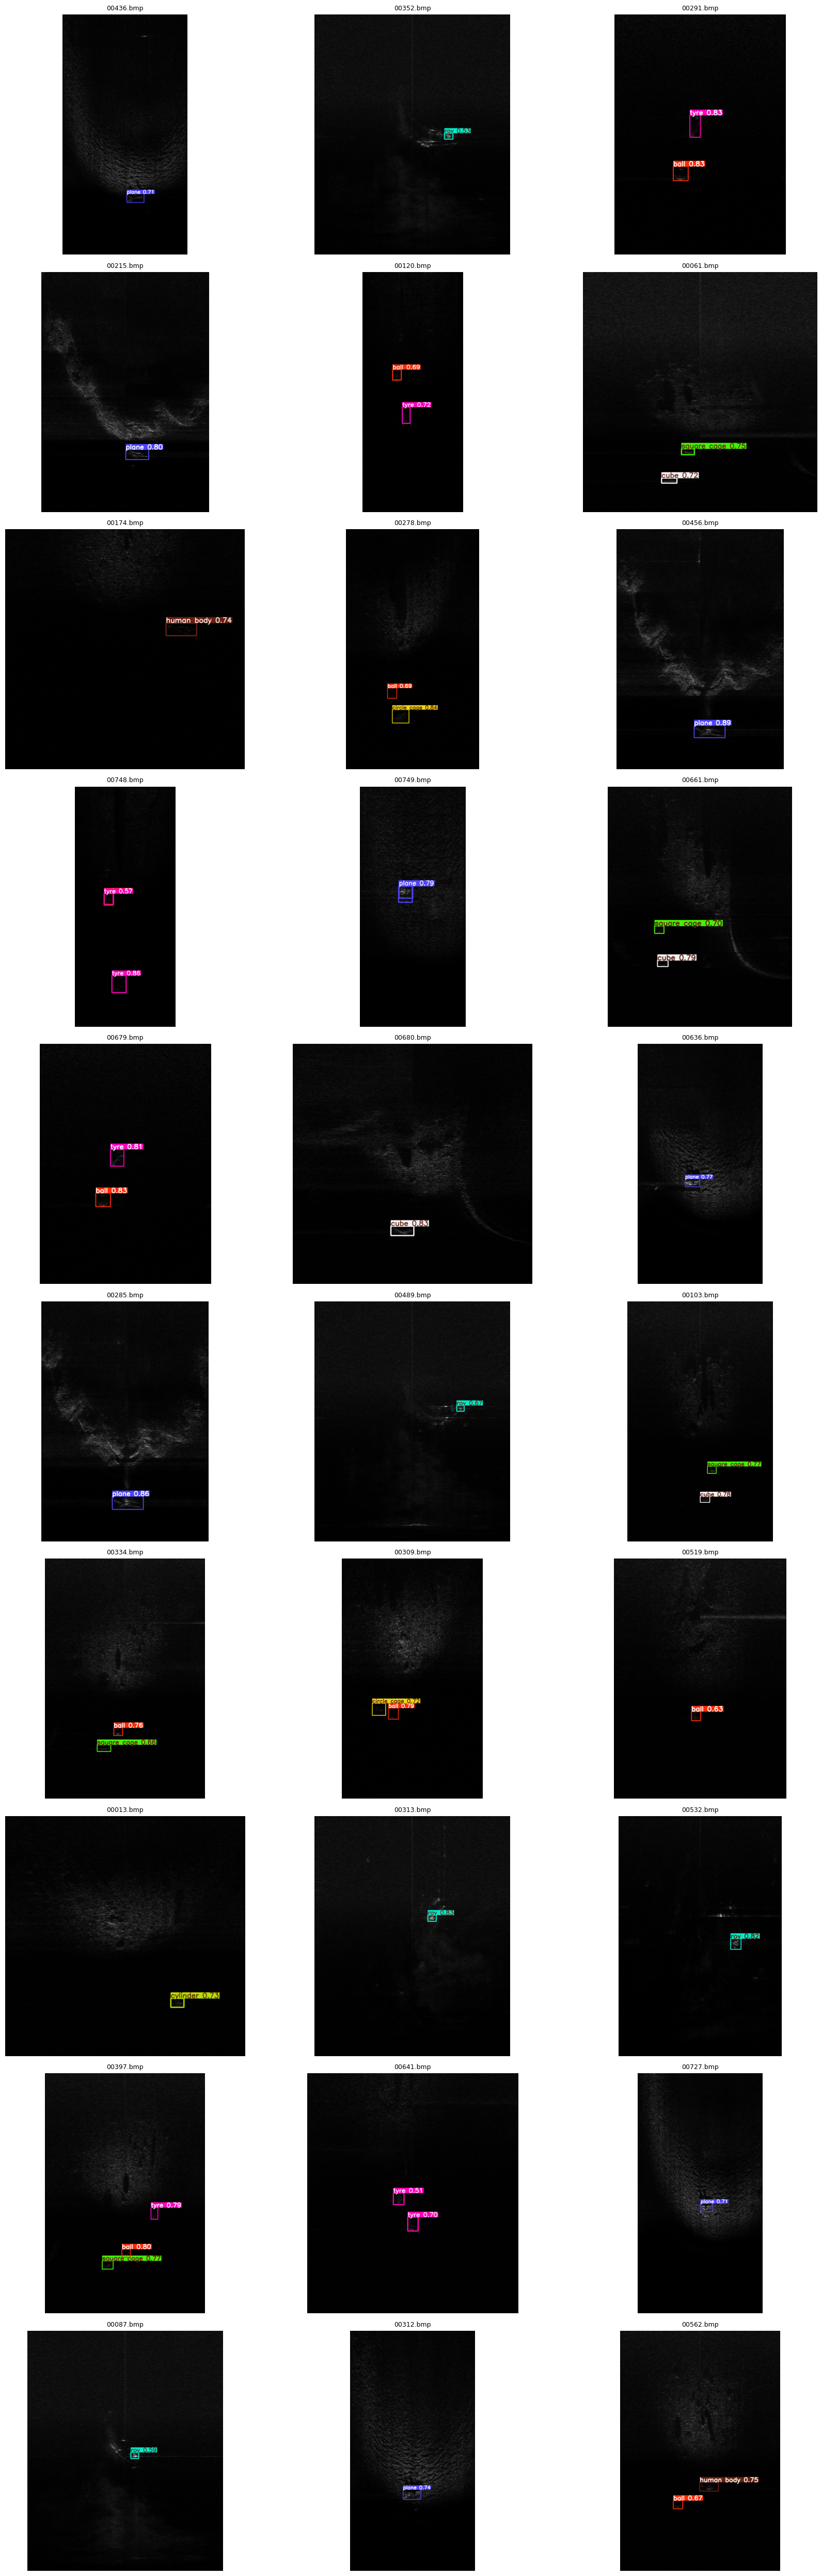

In [11]:
# Imports
from ultralytics import YOLO
import os
import random
import math
import matplotlib.pyplot as plt

# Load trained model
MODEL_PATH = "/kaggle/working/runs/detect/train/weights/best.pt"
model = YOLO(MODEL_PATH)

# Validation images directory
VAL_DIR = "/kaggle/input/underwater-acoustic-target-detection-uatddataset/UATD_Test_2/UATD_Test_2/images"

# Select random images
NUM_IMAGES = 30
image_files = os.listdir(VAL_DIR)
sample_images = random.sample(image_files, min(NUM_IMAGES, len(image_files)))

# Grid setup (3 images per row)
cols = 3
rows = math.ceil(len(sample_images) / cols)

plt.figure(figsize=(18, rows * 5))

for idx, img_name in enumerate(sample_images):
    img_path = os.path.join(VAL_DIR, img_name)

    #  Run inference
    results = model.predict(
        source=img_path,
        imgsz=640,
        conf=0.15,
        device=0,
        verbose=False
    )

    # Get image with boxes
    plotted_img = results[0].plot()

    # Show image
    plt.subplot(rows, cols, idx + 1)
    plt.imshow(plotted_img)
    plt.title(img_name, fontsize=9)
    plt.axis("off")

    # Print detections
    print(f"\n Image: {img_name}")
    if len(results[0].boxes) == 0:
        print("No detections")
    else:
        for box in results[0].boxes:
            cls_id = int(box.cls)
            conf = float(box.conf)
            name = model.names[cls_id]
            print(f" {name}: {conf:.2f}")

plt.tight_layout()
plt.show()


In [12]:
# CELL 1: Imports and paths

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

RESULTS_DIR = "/kaggle/working/runs/detect/train"
CSV_PATH = os.path.join(RESULTS_DIR, "results.csv")

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 120


In [14]:
# CELL 2: Load results.csv

df = pd.read_csv(CSV_PATH)
df.head(20)


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,126.700,2.01590,3.09577,1.16740,0.57012,0.59655,0.61991,0.25213,1.93576,1.62674,1.24729,0.000238,0.000238,0.000238
1,2,240.835,1.82599,1.63970,1.12481,0.69300,0.56915,0.62779,0.23124,2.19192,1.48635,1.34478,0.000452,0.000452,0.000452
2,3,352.845,1.78265,1.29001,1.11317,0.69520,0.61543,0.66941,0.26252,2.07568,1.56445,1.30198,0.000643,0.000643,0.000643
3,4,463.733,1.73759,1.12967,1.09907,0.65633,0.43178,0.49507,0.18780,2.30025,1.53016,1.44610,0.000608,0.000608,0.000608
4,5,574.307,1.70499,1.03135,1.08992,0.78402,0.73087,0.75692,0.30230,2.08509,1.32393,1.32317,0.000573,0.000573,0.000573
5,6,686.005,1.67034,0.96061,1.07804,0.75154,0.75362,0.74603,0.29913,2.05260,1.41566,1.30017,0.000537,0.000537,0.000537
6,7,797.424,1.63609,0.91508,1.06115,0.84316,0.79072,0.81180,0.32643,1.97460,1.25911,1.27476,0.000502,0.000502,0.000502
7,8,908.808,1.62295,0.88103,1.05790,0.81529,0.77439,0.79108,0.32253,1.99217,1.19044,1.28097,0.000467,0.000467,0.000467
8,9,1020.400,1.59878,0.84155,1.05034,0.82416,0.77299,0.77786,0.31111,2.02682,1.25473,1.31556,0.000431,0.000431,0.000431
9,10,1131.640,1.58310,0.81614,1.04358,0.86404,0.80622,0.83039,0.33735,2.02478,1.17920,1.30622,0.000396,0.000396,0.000396


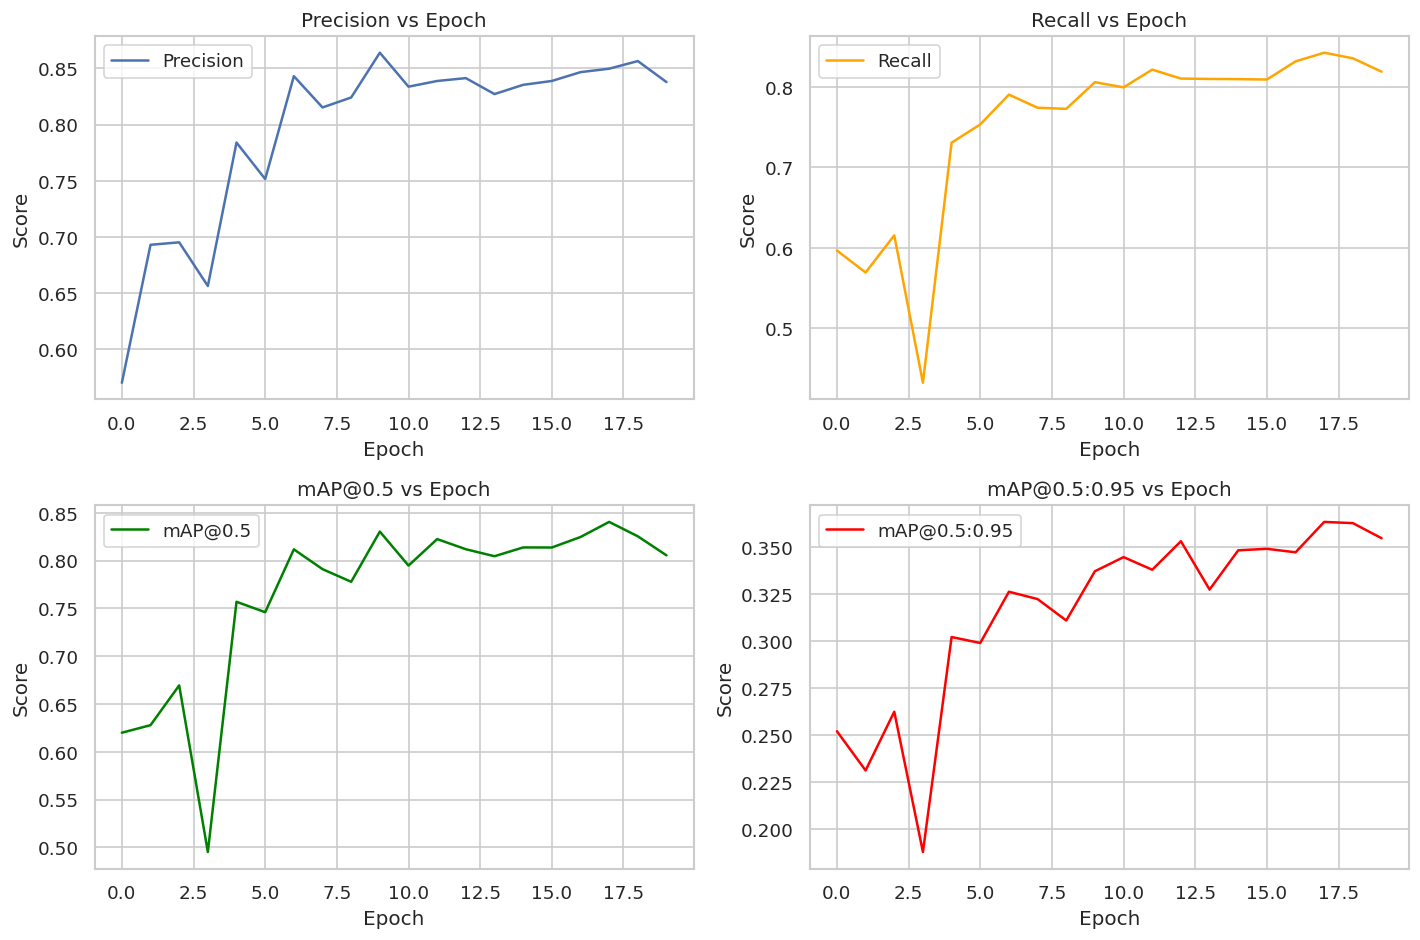

In [15]:
# CELL 3: Precision, Recall, mAP curves

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(df["metrics/precision(B)"], label="Precision")
axes[0, 0].set_title("Precision vs Epoch")

axes[0, 1].plot(df["metrics/recall(B)"], label="Recall", color="orange")
axes[0, 1].set_title("Recall vs Epoch")

axes[1, 0].plot(df["metrics/mAP50(B)"], label="mAP@0.5", color="green")
axes[1, 0].set_title("mAP@0.5 vs Epoch")

axes[1, 1].plot(df["metrics/mAP50-95(B)"], label="mAP@0.5:0.95", color="red")
axes[1, 1].set_title("mAP@0.5:0.95 vs Epoch")

for ax in axes.flat:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Score")
    ax.legend()

plt.tight_layout()
plt.show()


In [16]:
maps = [0.43738, 0.2491, 0.24752, 0.40251, 0.40013,
        0.26233, 0.65496, 0.42559, 0.18254, 0.37245]

class_names = [
    "Ball", "Circle Cage", "Cube", "Cylinder", "Human Body",
    "Metal Bucket", "Plane", "ROV", "Square Cage", "Tyre"
]


/tmp/ipykernel_55/2236658305.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=maps, palette="viridis")


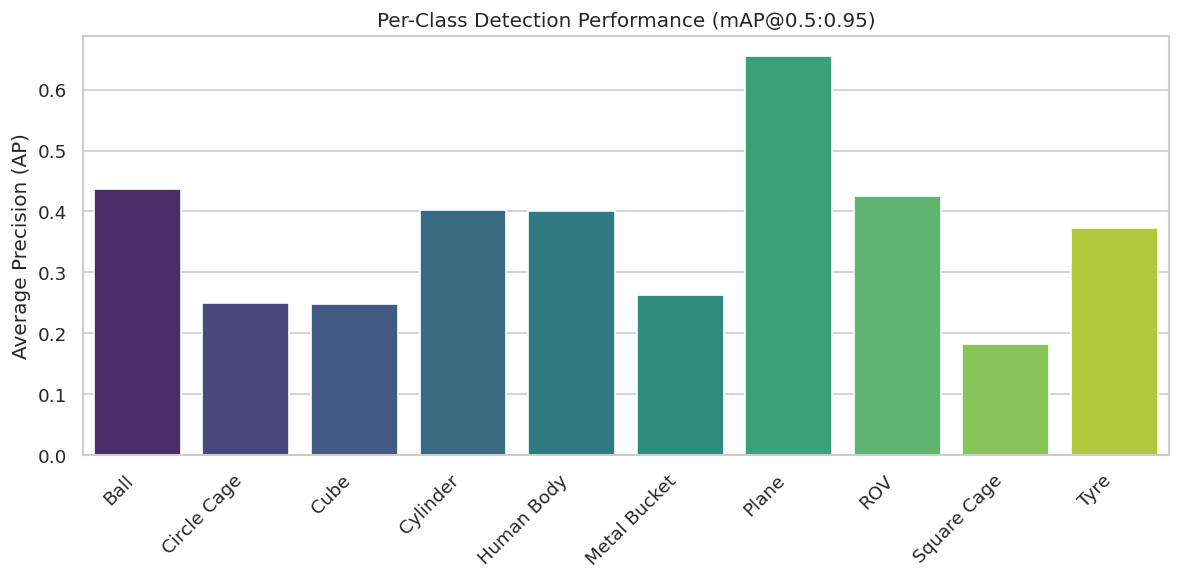

In [17]:
# CELL 4: Per-class AP bar chart

plt.figure(figsize=(10, 5))
sns.barplot(x=class_names, y=maps, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Precision (AP)")
plt.title("Per-Class Detection Performance (mAP@0.5:0.95)")
plt.tight_layout()
plt.show()


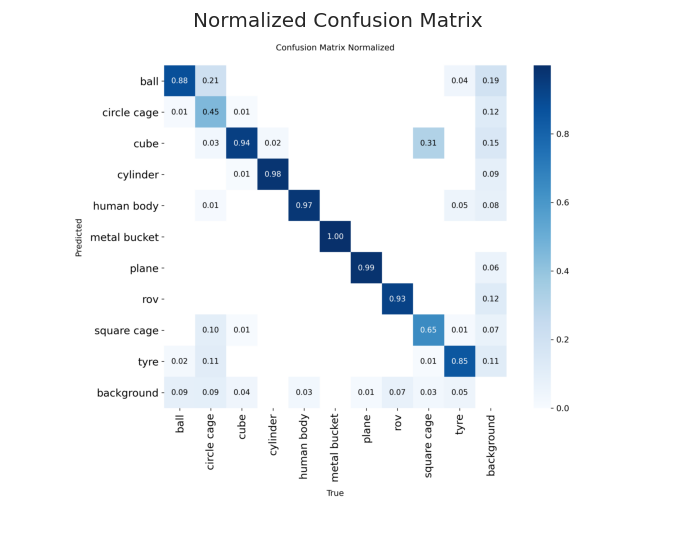

In [18]:
# CELL 5: Show confusion matrix image

from PIL import Image

cm_path = os.path.join(RESULTS_DIR, "confusion_matrix_normalized.png")

img = Image.open(cm_path)
plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.axis("off")
plt.title("Normalized Confusion Matrix")
plt.show()


In [19]:
# CELL 6: Inference speed summary

inference_ms = 1.577
fps = 1000 / inference_ms

speed_df = pd.DataFrame({
    "Metric": ["Inference Time (ms)", "FPS"],
    "Value": [inference_ms, fps]
})

speed_df


,Metric,Value
0,Inference Time (ms),1.577000
1,FPS,634.115409
